# Random Signal

- Jose Gonzalez Lopez

- Mykola Liashuha

# Imports

In [11]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np
import cv2 #Read images and do operations
import IPython.display as ipd



from scipy.io import wavfile #Read wavfiles
from scipy.signal import periodogram,welch #Get periodograms
from scipy.fft import fft, ifft,fftfreq #Fourier transform


# Auxiliar functions

In [12]:
'''
This fuction plots the fourier transform of an audio file
'''

def plot_fourier_transform(data, samplerate):
    N = data.shape[0]
    # sample spacing
    T = 1.0 / samplerate
    #Transform
    yf = fft(data)
    xf = fftfreq(N, T)[:N//10]
    #And plot
    plt.figure(figsize=(10,10))
    plt.xlabel('Freq (Hz)')
    plt.ylabel('FFT')
    plt.plot(xf, np.abs(yf)[:N//10])
    plt.show()

In [4]:
'''
This functin plots the periodogram of an audio file in the log scale
'''

def plot_periodogram(data,samplerate):
    #Get frecuency and estimate power spectrum
    f, P_den = periodogram(data, samplerate)
    
    #Clean the result, get positive values
    P_den = abs(P_den)**2
    P_den = P_den / sum(P_den)

    #Plot in logarithmic scale
    plt.semilogy(f, P_den)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.show()

In [5]:
'''
This function plots the welch method of an audio file in the log scale
'''

def plot_welch(data,samplerate):
    #Get frecuency and estimate power spectrum
    f, P_den = welch(data, samplerate)
    
    #Clean the result, get positive values
    P_den = abs(P_den)**2
    P_den = P_den / sum(P_den)

    #Plot in logarithmic scale
    plt.semilogy(f, P_den)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [V**2/Hz]')
    plt.show()

# Introduction
This is the intro

# 1. Noise analysis
In this section we will analyse the noise files given for this exercise

## Noise 1 

To see that the data file are noises, let's just do a little experiment by ploting the fourier transform of the noise and see what happens.

In [6]:
samplerate_1, data_1 = wavfile.read("noise1.wav") #Read the file
ipd.Audio(data_1, rate=samplerate_1)

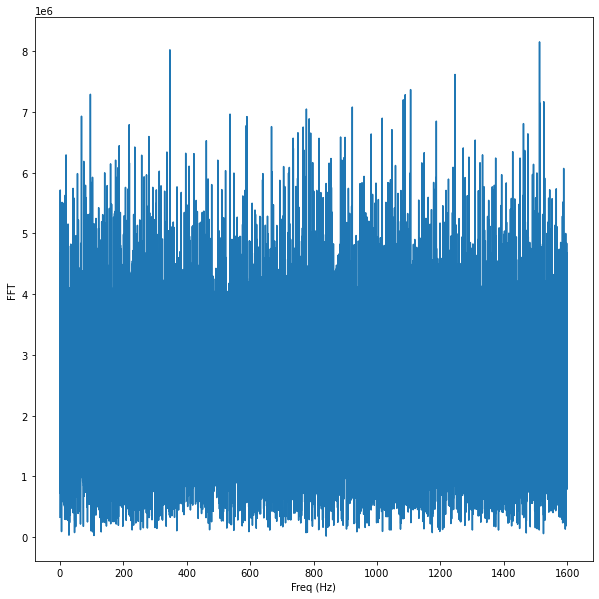

In [7]:
plot_fourier_transform(data_1, samplerate_1)

In the image above, the fourier transform cannot tell us any infomation about the signal because its plot is a total mess. This means that we are dealing with noise, a random signal. So, to actually analyse this data, we have to get its power spectrum

### Periodogram

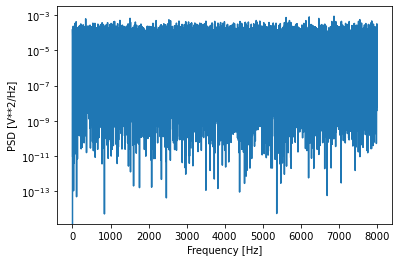

In [8]:
plot_periodogram(data_1,samplerate_1)

### Welsh method

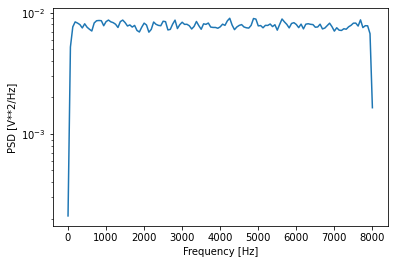

In [9]:
plot_welch(data_1,samplerate_1)

### Color identification

If we look at both images, the power spetrum seems to be stable during the whole audio, so this noise is behaving as a **white** noise.

## Noise 2

In [108]:
samplerate_2, data_2 = wavfile.read("noise2.wav") #Read the file
ipd.Audio(data_2, rate=samplerate_2)

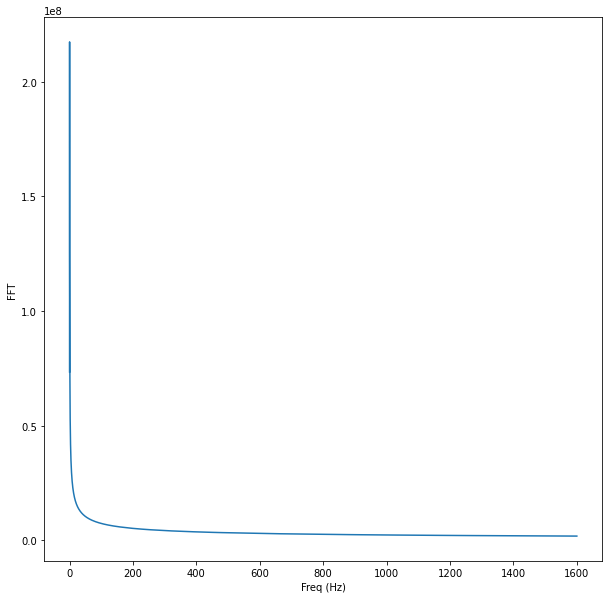

In [12]:
plot_fourier_transform(data_2, samplerate_2)

In this case, we have the opposite case than the last one. Seems that the Fourier Transform did not get any information at all, which in our opinion reflects the same effect as a random signal would do: not be certain about the signal.

### Periodogram

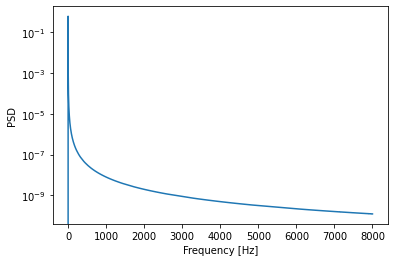

In [23]:
f, Pxx_den = periodogram(data_2, samplerate_2)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([1e-7, 1e2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD')
plt.show()

### Welsh method

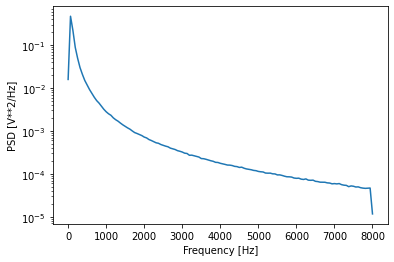

In [25]:
f, Pxx_den = welch(data_2, samplerate_2)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([0.5e-3, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

### Color identification

In [ ]:
#Code

## Noise 3

In [109]:
samplerate_3, data_3 = wavfile.read("noise3.wav") #Read the file
ipd.Audio(data_3, rate=samplerate_3)

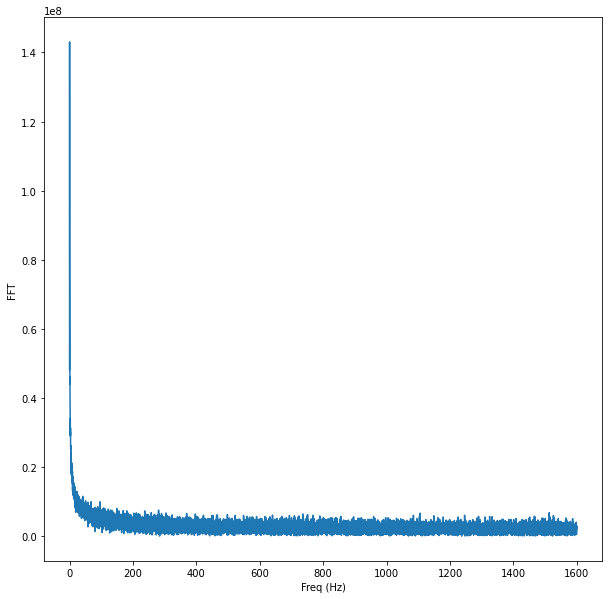

In [27]:
N = data_3.shape[0]
# sample spacing
T = 1.0 / samplerate_3
#Transform
yf = fft(data_3)
xf = fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

### Periodogram

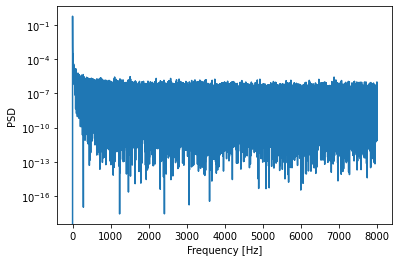

In [29]:
f, Pxx_den = periodogram(data_3, samplerate_3)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([1e-7, 1e2])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD')
plt.show()

### Welsh method

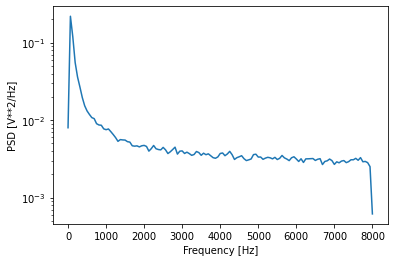

In [31]:
f, Pxx_den = welch(data_3, samplerate_3)
#Clean the result
Pxx_den = abs(Pxx_den)**2
Pxx_den = Pxx_den / sum(Pxx_den)

plt.semilogy(f, Pxx_den)
#plt.ylim([0.5e-3, 1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

### Color identification

In [ ]:
#Code

# 2. Image noising and denoising

Below we are going to present the way of applying noise to an image and afterwards denoising it with weiner filter.

In [25]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np
import cv2 #Read images and do operations
import numpy.random


from scipy.io import wavfile #Read wavfiles
from scipy.signal import periodogram,welch #Get periodograms
from scipy.fft import fft, fft2,ifft,ifft2, fftfreq #Fourier transform

First step is to read an original image (barbara.jpg)

In [160]:
img = cv2.imread('barbara.jpg',0) #Reading
height,width = img.shape #Getting essential features of image

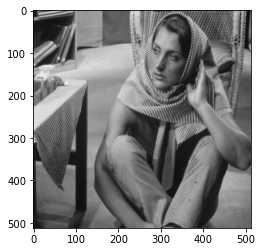

In [161]:
plt.imshow(img,cmap='gray')

Further we are going to apply some additional noise in this way:

$$y = x + sigma * generated\_normal\_samples$$

In [163]:
std = 0.08
noise = numpy.random.normal(0, 1, size=img.shape)

img_noise = img + std*noise

In [164]:
def snr(x, y):
    
    return 20*np.log10(np.mean(np.abs(x))/np.mean(np.abs(x-y)))

def denoise(img_noise, std):
    P = (1/(img_noise.shape[0]*img_noise.shape[1])) * np.power(np.abs(fft2(img_noise)), 2)
    h_w = np.real(ifft2( P / ( P + np.power(std, 2) ) ))
    res = np.real(ifft2(fft2(img_noise) *fft2(h_w)))
    return res


Below here is an example of SNR measurement. Signal-to-noise ratio displays how much noise we have in the signal basically by comparing desired signal with noise levels we have in the signal. SNR is computed in this way:
$$SNR(y∣x)=20*log( \frac{∥x∥}{∥x-y∥}) \\
where\ x\ is\ original\ signal,\ y\ is\ noisy\ signal\ and\ ∥\ is\ absolute\ norm\ (1st\ Norm)$$

Text(0.5, 1.0, 'SNR 64.83553976019608 dB')

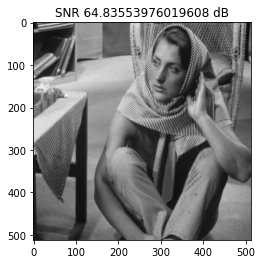

In [167]:
plt.imshow(img_noise,cmap='gray')
plt.title(f'SNR {snr(img,img_noise)} dB')

Below we are going to provide results for different levels of noise: 0, 5, 15 and 20 dB.

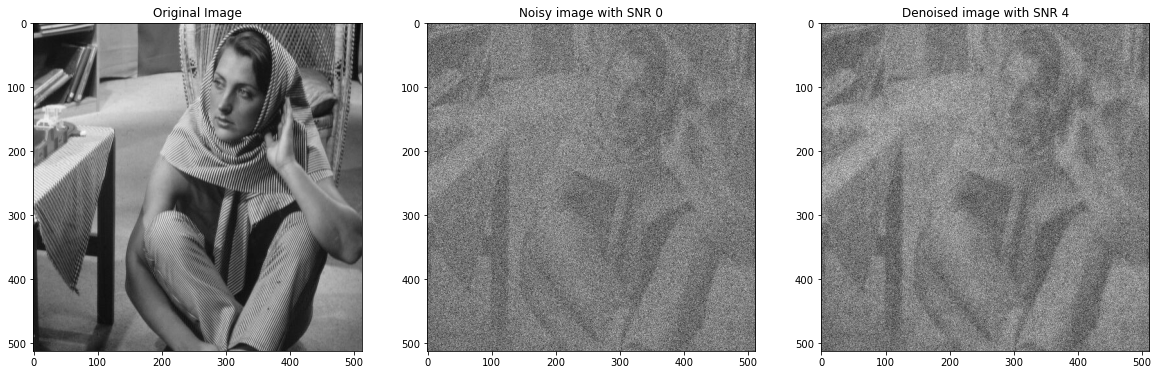

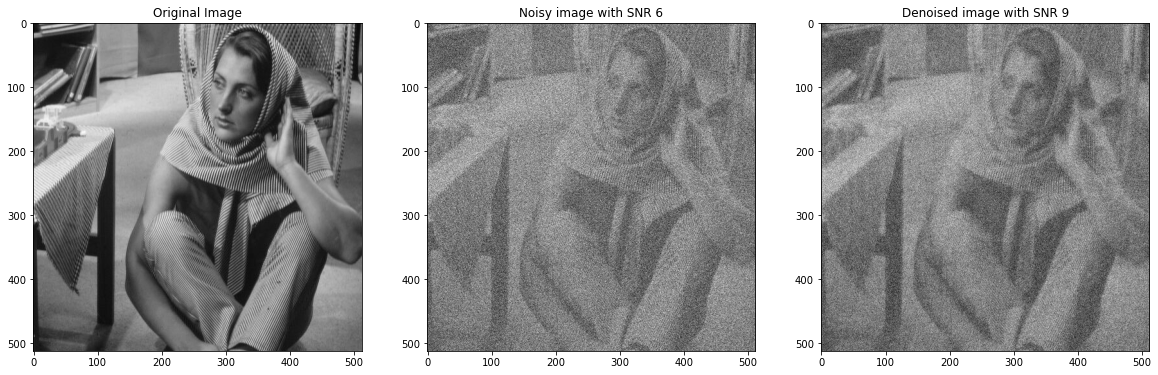

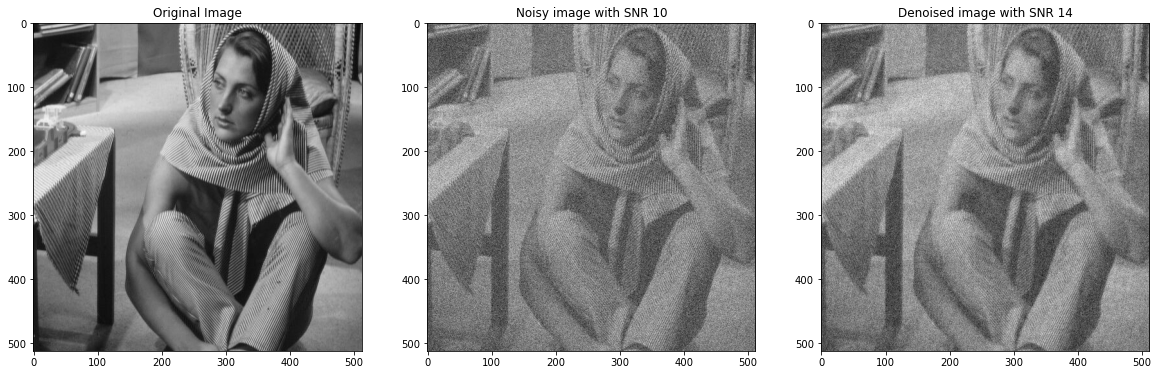

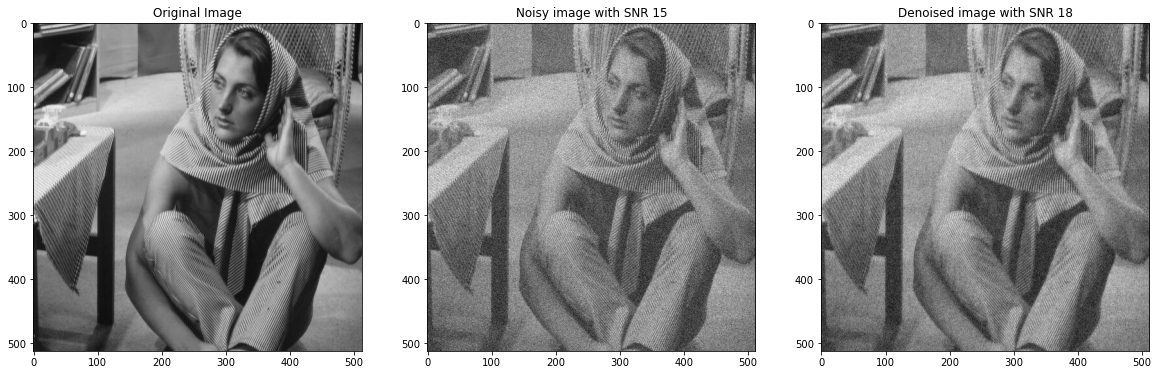

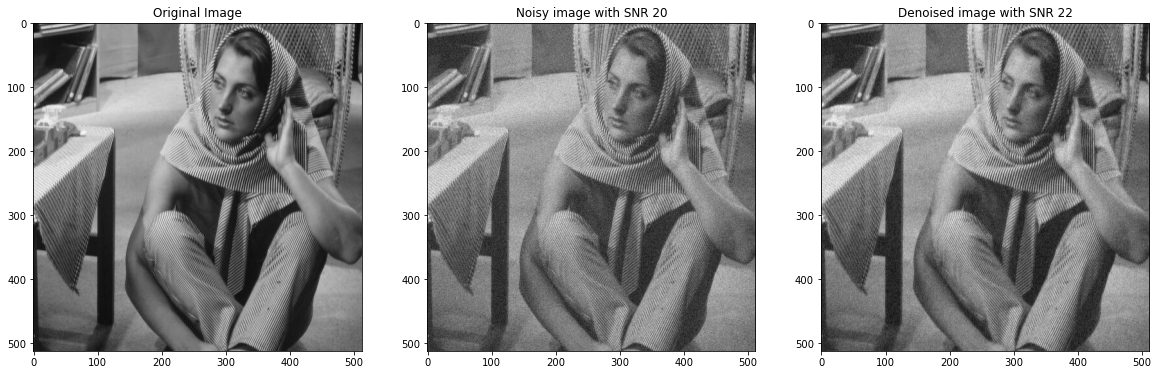

In [170]:
stds = [130,70,40, 24,13]
for std in stds:
#     std = 13
    noise = numpy.random.normal(0, 1, size=img.shape)

    img_noise = img + std*noise

    fig, axs = plt.subplots(1, 3)
    fig.set_figheight(20)
    fig.set_figwidth(20)
    axs[0].imshow(img,cmap='gray')
    axs[0].set_title('Original Image')
    axs[1].imshow(img_noise,cmap='gray')
    axs[1].set_title('Noisy image'+f' with SNR {int(snr(img,img_noise))}')
    denoised = denoise(img_noise, std)
    axs[2].imshow(denoised,cmap='gray')
    axs[2].set_title('Denoised image'+f' with SNR {int(snr(img,denoised))}')
    plt.show()

Overall, it was prooved that we managed to add Gaussian white noise to the image. And moreover, Weiner filter denoised our image since we meaasured the SNR value before and after denoising. And after denosing noisy image, the SNR measurements increased which means that in denoised image there appears more signal than noise comparing to noisy image (before denoising).

# 3. Music noising and denoising

In [2]:
samplerate_1, data_1 = wavfile.read("noise1.wav") #Read the file
samplerate_2, data_2 = wavfile.read("noise2.wav") #Read the file
samplerate_3, data_3 = wavfile.read("noise3.wav") #Read the file
samplerate_music, data_music = wavfile.read("music.wav") #Read the file

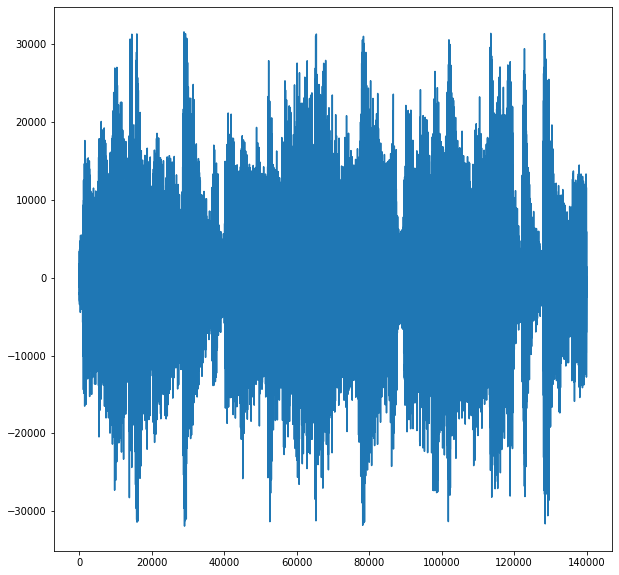

In [3]:
plt.figure(figsize=(10,10))
plt.plot(data_music)

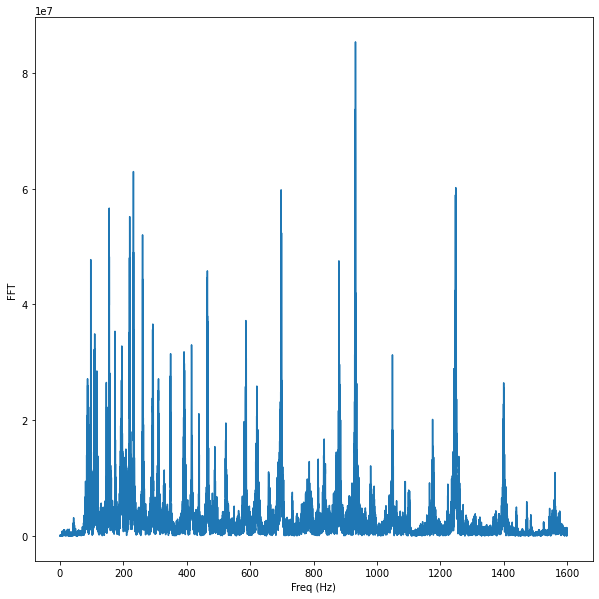

In [4]:
N = data_music.shape[0]
# sample spacing
T = 1.0 / samplerate_music
#Transform
yf = fft(data_music)
xf= fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

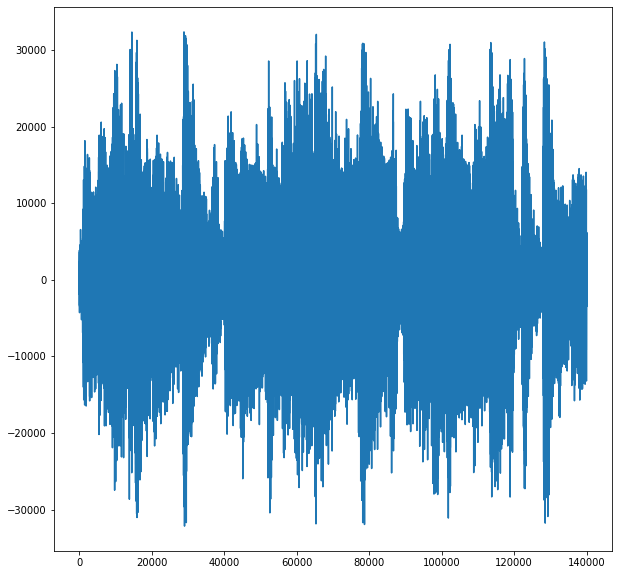

In [16]:
noisy_data_music=data_music+0.1*(data_1)
plt.figure(figsize=(10,10))
plt.plot(noisy_data_music)

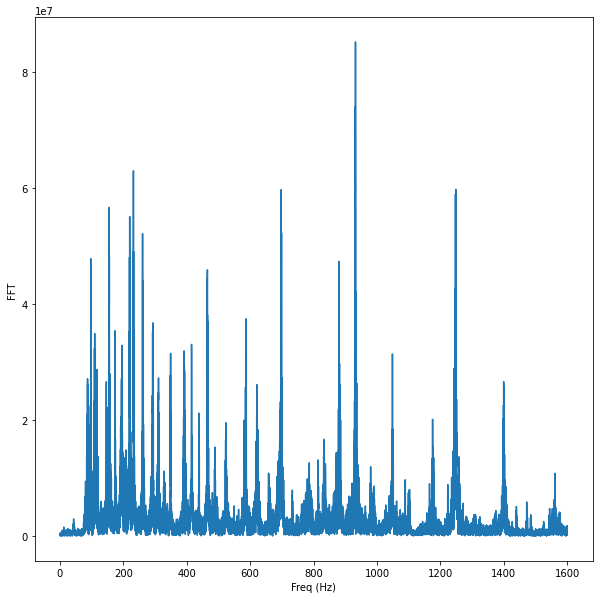

In [17]:
N = noisy_data_music.shape[0]
# sample spacing
T = 1.0 / samplerate_music
#Transform
yf = fft(noisy_data_music)
xf= fftfreq(N, T)[:N//10]
#And plot
plt.figure(figsize=(10,10))
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT')
plt.plot(xf, np.abs(yf)[:N//10])
plt.show()

In [28]:
N = data_music.shape[0]
N_2 = noisy_data_music.shape[0]
P = 1/N * np.abs(fft(data_music))**2 #Power of the original signal
P_2=1/N_2 * np.abs(fft(noisy_data_music))**2 #Power of noisy signañ
h_w = real(ifft(P/(P+P_2))) #Apply the filter
wiener = np.convolve(noisy_data_music,h_w) #And convolve

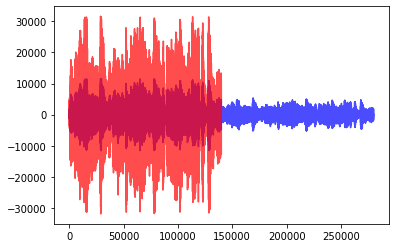

In [29]:
plt.plot(wiener,alpha=0.7,c='b')
plt.plot(data_music,alpha=0.7,c='r')
plt.show()

# References
https://www.youtube.com/watch?v=7STeeVnfYFM